# PCOS Dataset Cleaning and Inspection (Full Clinical Dataset)

## Introduction
This notebook is performing the first research-grade preprocessing stage for the MSc study on the early and non-invasive prediction of Polycystic Ovary Syndrome (PCOS). The work in this notebook is focusing on understanding, auditing, and cleaning the primary clinical dataset before any exploratory analysis, statistical testing, or predictive modeling is being carried out.

The notebook is working with the file `PCOS_data_without_infertility.xlsx`, specifically the main clinical sheet in the workbook. This dataset is serving as the main analytical foundation for the study because it contains clinical, demographic, and symptom-related variables that can support the identification of PCOS using routine health information. At this stage, the emphasis is remaining on data quality, consistency, transparency, and reproducibility.

## Research Context
The broader research is investigating whether routinely collected clinical and lifestyle-related variables can support the early detection of PCOS in a way that is practical, accessible, and low in diagnostic burden. This is aligning with the study objective of improving screening using non-invasive or low-resource indicators rather than depending solely on expensive hormonal testing, imaging, or other specialized procedures.

The notebook is therefore establishing a clean and reliable version of the full clinical PCOS dataset that can later support:
- exploratory data analysis
- feature assessment for non-invasive PCOS prediction
- association studies involving cardiometabolic risk indicators
- downstream model development and validation

## What This Notebook Is Doing
This notebook is:
- loading and inspecting the full clinical PCOS dataset
- reviewing structure, variable types, descriptive statistics, and data quality
- standardizing column names into a consistent analysis-ready format
- identifying and handling missing values and duplicate records
- checking unit consistency and validating clinically plausible numeric ranges
- deriving reusable features such as body mass index and waist-hip ratio where required
- exporting a cleaned dataset for later notebooks in the research pipeline

## Expected Output
The primary output of this notebook is a cleaned and standardized dataset saved as:

`./cleaned_data/PCOS_full_cleaned.csv`

Supporting outputs may also include summary tables, a transformation log, and diagnostic figures saved to `./images/` to preserve traceability and support later interpretation.

## Notebook Structure
The sections that are following are being organized as a step-by-step cleaning workflow:

1. **Reproducibility Setup and Path Configuration**  
   The project paths are being resolved in a notebook-safe way so the workflow can run from the repository root or the `notebooks/` directory.

2. **Data Loading and Initial Inspection**  
   The workbook is being loaded and inspected for shape, columns, sample records, and descriptive summaries.

3. **Column Standardization**  
   Variable names are being cleaned and renamed into a consistent naming scheme suitable for downstream analysis.

4. **Data Quality Assessment**  
   Missing values, duplicate rows, inconsistent encodings, and potentially invalid entries are being identified and summarized.

5. **Unit Validation and Feature Preparation**  
   Measurement units are being reviewed, and derived variables are being created where needed.

6. **Dataset Export and Cleaning Summary**  
   The cleaned dataset is being saved, and all major transformations are being documented for reproducibility.

## Reproducibility Note
All paths in this notebook are being kept relative to the project structure, and all cleaning decisions that change the analytical dataset are being documented so that the workflow can be rerun consistently and audited later.

## Reproducibility Setup and Path Configuration

This section is preparing the notebook environment, importing the required libraries, and resolving project paths in a way that remains stable across machines and execution directories.

In [1]:
# Importing the libraries that are supporting data handling, reporting, and figure generation.
from pathlib import Path
import io
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# Importing seaborn when it is available keeps the plots visually consistent, while a matplotlib fallback preserves portability.
try:
    import seaborn as sns
    sns.set_theme(style='whitegrid', context='notebook')
except ImportError:
    sns = None
    plt.style.use('seaborn-v0_8-whitegrid')

# Setting notebook display options is making the wide clinical table easier to inspect.
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')

# Fixing a random seed now keeps any future sampling or stochastic checks reproducible.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Resolving the project root dynamically allows this notebook to run from the repo root or the notebooks directory.
def resolve_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / 'data' / 'PCOS_data_without_infertility.xlsx').exists():
            return candidate
    raise FileNotFoundError('The PCOS workbook could not be located relative to the current working directory.')

PROJECT_ROOT = resolve_project_root()
DATA_PATH = PROJECT_ROOT / 'data' / 'PCOS_data_without_infertility.xlsx'
CLEANED_DIR = PROJECT_ROOT / 'cleaned_data'
IMAGE_DIR = PROJECT_ROOT / 'images'

# Creating output directories keeps the export steps idempotent across reruns.
CLEANED_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

display(Markdown(f'**Project root:** `{PROJECT_ROOT}`'))
display(Markdown(f'**Raw workbook:** `{DATA_PATH}`'))
display(Markdown(f'**Cleaned data directory:** `{CLEANED_DIR}`'))
display(Markdown(f'**Image directory:** `{IMAGE_DIR}`'))

**Project root:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic`

**Raw workbook:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\data\PCOS_data_without_infertility.xlsx`

**Cleaned data directory:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data`

**Image directory:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images`

## Data Loading

This section is loading the main clinical PCOS workbook and selecting the appropriate sheet for the full dataset. The loading logic is remaining resilient to the workbook naming variation observed in the raw file.

In [2]:
# Reading the workbook first allows the notebook to inspect available sheet names before selecting the study dataset.
workbook = pd.ExcelFile(DATA_PATH)
candidate_sheets = ['Full Data', 'Full_new']

# Choosing the intended full-data sheet with a fallback keeps the notebook aligned with both the plan and the raw workbook.
selected_sheet = next((sheet for sheet in candidate_sheets if sheet in workbook.sheet_names), workbook.sheet_names[0])
df_raw = pd.read_excel(DATA_PATH, sheet_name=selected_sheet)

display(Markdown(f'**Selected sheet:** `{selected_sheet}`'))
display(Markdown('**Available sheets:** ' + ', '.join(f'`{sheet}`' for sheet in workbook.sheet_names)))

# Showing the first ten rows provides an initial sense of structure and coding patterns.
df_raw.head(10)

**Selected sheet:** `Full_new`

**Available sheets:** `Instructions`, `Full_new`

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),Cycle length(days),Marraige Status (Yrs),Pregnant(Y/N),No. of aborptions,I beta-HCG(mIU/mL),II beta-HCG(mIU/mL),FSH(mIU/mL),LH(mIU/mL),FSH/LH,Hip(inch),Waist(inch),Waist:Hip Ratio,TSH (mIU/L),AMH(ng/mL),PRL(ng/mL),Vit D3 (ng/mL),PRG(ng/mL),RBS(mg/dl),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.600,152.000,19.300,15,78,22,10.480,2,5,7.000,0,0,1.990,1.990,7.950,3.680,2.160,36,30,0.833,0.680,2.070,45.160,17.100,0.570,92.000,0,0,0,0,0,1.000,0,110,80,3,3,18.000,18.000,8.500,NaN
1,2,2,0,36,65.000,161.500,24.921,15,74,20,11.700,2,5,11.000,1,0,60.800,1.990,6.730,1.090,6.174,38,32,0.842,3.160,1.530,20.090,61.300,0.970,92.000,0,0,0,0,0,0.000,0,120,70,3,5,15.000,14.000,3.700,NaN
2,3,3,1,33,68.800,165.000,25.271,11,72,18,11.800,2,5,10.000,1,0,494.080,494.080,5.540,0.880,6.295,40,36,0.900,2.540,6.630,10.520,49.700,0.360,84.000,0,0,0,1,1,1.000,0,120,80,13,15,18.000,20.000,10.000,NaN
3,4,4,0,37,65.000,148.000,29.675,13,72,20,12.000,2,5,4.000,0,0,1.990,1.990,8.060,2.360,3.415,42,36,0.857,16.410,1.220,36.900,33.400,0.360,76.000,0,0,0,0,0,0.000,0,120,70,2,2,15.000,14.000,7.500,NaN
4,5,5,0,25,52.000,161.000,20.061,11,72,18,10.000,2,5,1.000,1,0,801.450,801.450,3.980,0.900,4.422,37,30,0.811,3.570,2.260,30.090,43.800,0.380,84.000,0,0,0,1,0,0.000,0,120,80,3,4,16.000,14.000,7.000,NaN
5,6,6,0,36,74.100,165.000,27.218,15,78,28,11.200,2,5,8.000,1,0,237.970,1.990,3.240,1.070,3.028,44,38,0.864,1.600,6.740,16.180,52.400,0.300,76.000,1,0,0,1,0,0.000,0,110,70,9,6,16.000,20.000,8.000,NaN
6,7,7,0,34,64.000,156.000,26.298,11,72,18,10.900,2,5,2.000,0,0,1.990,1.990,2.850,0.310,9.194,39,33,0.846,1.510,3.050,26.410,42.700,0.460,93.000,0,0,0,0,0,0.000,0,120,80,6,6,15.000,16.000,6.800,NaN
7,8,8,0,33,58.500,159.000,23.140,13,72,20,11.000,2,5,13.000,1,2,100.510,100.510,4.860,3.070,1.583,44,38,0.864,12.180,1.540,3.970,38.000,0.260,91.000,1,0,0,0,0,0.000,0,120,80,7,6,15.000,18.000,7.100,NaN
8,9,9,0,32,40.000,158.000,16.023,11,72,18,11.800,2,5,8.000,0,1,1.990,1.990,3.760,3.020,1.245,39,35,0.897,1.510,1,19.000,21.800,0.300,116.000,0,0,0,0,0,0.000,0,120,80,5,7,17.000,17.000,4.200,NaN
9,10,10,0,36,52.000,150.000,23.111,15,80,20,10.000,4,2,4.000,0,0,1.990,1.990,2.800,1.510,1.854,40,38,0.950,6.650,1.610,11.740,27.700,0.250,125.000,0,0,0,0,0,0.000,0,110,80,1,1,14.000,17.000,2.500,NaN


## Initial Inspection and Descriptive Summary

The following checks are inspecting the raw structure of the dataset, including dimensions, column types, descriptive statistics, missing values, and duplicate patterns before any cleaning is being applied.

In [4]:
# Capturing dataframe info in a text buffer makes the schema report easier to display inside the notebook.
info_buffer = io.StringIO()
df_raw.info(buf=info_buffer)

# Creating compact overview tables keeps the initial audit readable and thesis-friendly.
dataset_shape = pd.DataFrame(
    {
        'metric': ['rows', 'columns'],
        'value': [df_raw.shape[0], df_raw.shape[1]],
    }
)
raw_missing_summary = (
    pd.DataFrame(
        {
            'column': df_raw.columns,
            'missing_count': df_raw.isna().sum().values,
            'missing_percentage': (df_raw.isna().sum().values / len(df_raw)) * 100,
        }
    )
    .sort_values(['missing_count', 'column'], ascending=[False, True])
    .reset_index(drop=True)
)
raw_duplicate_rows = int(df_raw.duplicated().sum())
identifier_columns = [column for column in ['Sl. No', 'Patient File No.'] if column in df_raw.columns]
raw_identifier_duplicates = int(df_raw.duplicated(subset=identifier_columns).sum()) if identifier_columns else 0

# Displaying the inspection outputs provides a baseline that the later cleaning summary can compare against.
display(Markdown('### Raw Dataset Shape'))
display(dataset_shape)
display(Markdown('### Raw Data Types'))
print(info_buffer.getvalue())
display(Markdown('### Descriptive Statistics (All Columns)'))
display(df_raw.describe(include='all').T)
display(Markdown('### Missing-Value Summary'))
display(raw_missing_summary)
display(Markdown('### Duplicate Summary'))
display(
    pd.DataFrame(
        {
            'check': ['Exact duplicate rows', 'Duplicate rows using identifier fields'],
            'count': [raw_duplicate_rows, raw_identifier_duplicates],
        }
    )
)

### Raw Dataset Shape

,metric,value
0,rows,541
1,columns,45


### Raw Data Types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    in

### Descriptive Statistics (All Columns)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Sl. No,541.000,NaN,NaN,NaN,271.000,156.318,1.000,136.000,271.000,406.000,541.000
Patient File No.,541.000,NaN,NaN,NaN,271.000,156.318,1.000,136.000,271.000,406.000,541.000
PCOS (Y/N),541.000,NaN,NaN,NaN,0.327,0.470,0.000,0.000,0.000,1.000,1.000
Age (yrs),541.000,NaN,NaN,NaN,31.431,5.411,20.000,28.000,31.000,35.000,48.000
Weight (Kg),541.000,NaN,NaN,NaN,59.637,11.028,31.000,52.000,59.000,65.000,108.000
Height(Cm),541.000,NaN,NaN,NaN,156.485,6.034,137.000,152.000,156.000,160.000,180.000
BMI,541.000,NaN,NaN,NaN,24.311,4.056,12.418,21.641,24.238,26.635,38.900
Blood Group,541.000,NaN,NaN,NaN,13.802,1.841,11.000,13.000,14.000,15.000,18.000
Pulse rate(bpm),541.000,NaN,NaN,NaN,73.248,4.430,13.000,72.000,72.000,74.000,82.000
RR (breaths/min),541.000,NaN,NaN,NaN,19.244,1.689,16.000,18.000,18.000,20.000,28.000


### Missing-Value Summary

,column,missing_count,missing_percentage
0,Unnamed: 44,539,99.630
1,Fast food (Y/N),1,0.185
2,Marraige Status (Yrs),1,0.185
3,I beta-HCG(mIU/mL),0,0.000
4,Age (yrs),0,0.000
5,AMH(ng/mL),0,0.000
6,Avg. F size (L) (mm),0,0.000
7,Avg. F size (R) (mm),0,0.000
8,BMI,0,0.000
9,BP _Diastolic (mmHg),0,0.000


### Duplicate Summary

,check,count
0,Exact duplicate rows,0
1,Duplicate rows using identifier fields,0


## Column Standardization and Identifier Review

The following steps are standardizing the variable names for consistency, removing empty or non-informative identifier columns, and preserving a transparent raw-to-clean rename map for later reference across notebooks.

In [5]:
# Copying the raw dataframe protects the original import so that each cleaning decision can be traced clearly.
df = df_raw.copy()
transformation_log = []

# Recording transformation steps in a simple list keeps the workflow transparent and exportable.
def log_transformation(step: str, detail: str, affected_items: int) -> None:
    transformation_log.append(
        {
            'step': step,
            'detail': detail,
            'affected_items': affected_items,
        }
    )

# Removing empty or unnamed columns prevents accidental propagation of workbook artefacts into the cleaned dataset.
empty_columns = [column for column in df.columns if not str(column).strip() or str(column).lower().startswith('unnamed')]
if empty_columns:
    df = df.drop(columns=empty_columns)
    log_transformation('Dropped empty columns', f'Removed workbook artefact columns: {empty_columns}', len(empty_columns))

# Removing purely administrative identifiers prevents non-clinical keys from leaking into later analysis.
identifier_columns = [column for column in ['Sl. No', 'Patient File No.'] if column in df.columns]
if identifier_columns:
    df = df.drop(columns=identifier_columns)
    log_transformation('Dropped identifier columns', f'Removed non-informative identifier columns: {identifier_columns}', len(identifier_columns))

# Building an explicit rename map ensures that clinically important columns keep stable names across future notebooks.
explicit_rename_map = {
    'PCOS (Y/N)': 'pcos_y_n',
    ' Age (yrs)': 'age_yrs',
    'Weight (Kg)': 'weight_kg',
    'Height(Cm) ': 'height_cm',
    'BMI': 'bmi',
    'Blood Group': 'blood_group_code',
    'Pulse rate(bpm) ': 'pulse_rate_bpm',
    'RR (breaths/min)': 'respiratory_rate_breaths_min',
    'Hb(g/dl)': 'hb_g_dl',
    'Cycle(R/I)': 'cycle_regularity_code',
    'Cycle length(days)': 'cycle_length_days',
    'Marraige Status (Yrs)': 'marriage_status_yrs',
    'Pregnant(Y/N)': 'pregnant_y_n',
    'No. of aborptions': 'number_of_abortions',
    '  I   beta-HCG(mIU/mL)': 'beta_hcg_i_miu_ml',
    'II    beta-HCG(mIU/mL)': 'beta_hcg_ii_miu_ml',
    'FSH(mIU/mL)': 'fsh_miu_ml',
    'LH(mIU/mL)': 'lh_miu_ml',
    'FSH/LH': 'fsh_lh_ratio',
    'Hip(inch)': 'hip_inch',
    'Waist(inch)': 'waist_inch',
    'Waist:Hip Ratio': 'waist_hip_ratio',
    'TSH (mIU/L)': 'tsh_miu_l',
    'AMH(ng/mL)': 'amh_ng_ml',
    'PRL(ng/mL)': 'prl_ng_ml',
    'Vit D3 (ng/mL)': 'vit_d3_ng_ml',
    'PRG(ng/mL)': 'prg_ng_ml',
    'RBS(mg/dl)': 'rbs_mg_dl',
    'Weight gain(Y/N)': 'weight_gain_y_n',
    'hair growth(Y/N)': 'hair_growth_y_n',
    'Skin darkening (Y/N)': 'skin_darkening_y_n',
    'Hair loss(Y/N)': 'hair_loss_y_n',
    'Pimples(Y/N)': 'pimples_y_n',
    'Fast food (Y/N)': 'fast_food_y_n',
    'Reg.Exercise(Y/N)': 'regular_exercise_y_n',
    'BP _Systolic (mmHg)': 'systolic_bp_mmhg',
    'BP _Diastolic (mmHg)': 'diastolic_bp_mmhg',
    'Follicle No. (L)': 'follicle_no_left',
    'Follicle No. (R)': 'follicle_no_right',
    'Avg. F size (L) (mm)': 'avg_follicle_size_left_mm',
    'Avg. F size (R) (mm)': 'avg_follicle_size_right_mm',
    'Endometrium (mm)': 'endometrium_mm',
}

# Providing a fallback name cleaner avoids silent failures if the raw workbook adds columns later.
def fallback_standardize(name: str) -> str:
    cleaned = str(name).strip().lower()
    cleaned = re.sub(r'[^a-z0-9]+', '_', cleaned)
    cleaned = re.sub(r'_+', '_', cleaned).strip('_')
    return cleaned

rename_map = {column: explicit_rename_map.get(column, fallback_standardize(column)) for column in df.columns}
rename_log = pd.DataFrame(
    {
        'original_name': list(rename_map.keys()),
        'standardized_name': list(rename_map.values()),
    }
)
columns_renamed_count = int((rename_log['original_name'] != rename_log['standardized_name']).sum())

# Guarding against duplicate standardized names prevents later overwrite bugs.
if rename_log['standardized_name'].duplicated().any():
    duplicate_names = rename_log.loc[rename_log['standardized_name'].duplicated(), 'standardized_name'].tolist()
    raise ValueError(f'Duplicate standardized names detected: {duplicate_names}')

df = df.rename(columns=rename_map)
log_transformation('Standardized column names', 'Renamed clinical variables to stable snake_case names.', columns_renamed_count)

display(Markdown('### Raw-to-Standardized Column Mapping'))
display(rename_log.sort_values('standardized_name').reset_index(drop=True))

### Raw-to-Standardized Column Mapping

,original_name,standardized_name
0,Age (yrs),age_yrs
1,AMH(ng/mL),amh_ng_ml
2,Avg. F size (L) (mm),avg_follicle_size_left_mm
3,Avg. F size (R) (mm),avg_follicle_size_right_mm
4,I beta-HCG(mIU/mL),beta_hcg_i_miu_ml
5,II beta-HCG(mIU/mL),beta_hcg_ii_miu_ml
6,Blood Group,blood_group_code
7,BMI,bmi
8,Cycle length(days),cycle_length_days
9,Cycle(R/I),cycle_regularity_code


## Cleaning, Unit Checks, and Feature Preparation

This section is converting the clinical variables into analysis-ready formats, standardizing binary encodings, deriving reusable anthropometric features, handling missingness, and documenting each material change that is being made to the dataset.

In [7]:
# Working on a dedicated cleaned copy keeps the standardized raw version available for comparison if needed.
df_clean = df.copy()

# Converting every analysis column to numeric is appropriate here because the raw sheet is storing coded clinical fields and measurements.
for column in df_clean.columns:
    df_clean[column] = pd.to_numeric(df_clean[column], errors='coerce')

# Defining the expected binary fields allows the notebook to validate the common yes/no symptom variables consistently.
binary_columns = [
    'pcos_y_n',
    'pregnant_y_n',
    'weight_gain_y_n',
    'hair_growth_y_n',
    'skin_darkening_y_n',
    'hair_loss_y_n',
    'pimples_y_n',
    'fast_food_y_n',
    'regular_exercise_y_n',
]
binary_map = {
    'y': 1,
    'n': 0,
    'yes': 1,
    'no': 0,
    '1': 1,
    '0': 0,
    '1.0': 1,
    '0.0': 0,
}
binary_validation_records = []

# Normalizing binary columns to 0/1 retains semantic consistency across later notebooks and exported datasets.
for column in binary_columns:
    if column not in df_clean.columns:
        continue
    as_text = (
        df_clean[column]
        .astype('string')
        .str.strip()
        .str.lower()
        .replace({'<na>': pd.NA, 'nan': pd.NA, '': pd.NA})
    )
    normalized = as_text.map(binary_map)
    numeric_fallback = pd.to_numeric(df_clean[column], errors='coerce')
    df_clean[column] = normalized.fillna(numeric_fallback)
    unexpected_values = sorted(set(df_clean[column].dropna().unique()) - {0.0, 1.0})
    binary_validation_records.append(
        {
            'column': column,
            'unexpected_values_before_imputation': unexpected_values,
        }
    )

# Dropping records with missing target labels avoids leaking imputed outcome values into future analysis.
missing_target_rows = int(df_clean['pcos_y_n'].isna().sum())
if missing_target_rows:
    df_clean = df_clean.loc[df_clean['pcos_y_n'].notna()].copy()
    log_transformation('Dropped missing target rows', 'Removed rows where the PCOS label was unavailable.', missing_target_rows)

# Removing exact duplicates after identifier removal targets duplicate clinical observations rather than duplicate file numbers.
duplicate_rows_after_identifier_drop = int(df_clean.duplicated().sum())
if duplicate_rows_after_identifier_drop:
    df_clean = df_clean.drop_duplicates().copy()
    log_transformation('Removed duplicate clinical rows', 'Dropped duplicate records after administrative identifiers were removed.', duplicate_rows_after_identifier_drop)

# Recomputing BMI and waist-hip ratio creates reusable validation features from the original anthropometric measurements.
df_clean['bmi_calculated'] = df_clean['weight_kg'] / ((df_clean['height_cm'] / 100) ** 2)
df_clean['waist_hip_ratio_calculated'] = df_clean['waist_inch'] / df_clean['hip_inch']

# Backfilling missing derived measures from the recalculated values preserves information without changing observed measurements that already exist.
bmi_missing_before = int(df_clean['bmi'].isna().sum()) if 'bmi' in df_clean.columns else 0
if bmi_missing_before:
    df_clean['bmi'] = df_clean['bmi'].fillna(df_clean['bmi_calculated'])
    log_transformation('Backfilled BMI', 'Filled missing BMI values from weight and height measurements.', bmi_missing_before)

waist_hip_missing_before = int(df_clean['waist_hip_ratio'].isna().sum()) if 'waist_hip_ratio' in df_clean.columns else 0
if waist_hip_missing_before:
    df_clean['waist_hip_ratio'] = df_clean['waist_hip_ratio'].fillna(df_clean['waist_hip_ratio_calculated'])
    log_transformation('Backfilled waist-hip ratio', 'Filled missing waist-hip ratio values from waist and hip measurements.', waist_hip_missing_before)

# Defining plausible clinical ranges supports a conservative sanity check before imputation is applied.
range_rules = {
    'age_yrs': (12, 100),
    'weight_kg': (20, 250),
    'height_cm': (120, 220),
    'bmi': (10, 70),
    'pulse_rate_bpm': (30, 220),
    'respiratory_rate_breaths_min': (5, 60),
    'hb_g_dl': (3, 20),
    'cycle_length_days': (1, 365),
    'systolic_bp_mmhg': (70, 250),
    'diastolic_bp_mmhg': (40, 150),
    'waist_inch': (15, 80),
    'hip_inch': (20, 90),
    'waist_hip_ratio': (0.40, 1.50),
    'rbs_mg_dl': (40, 400),
    'endometrium_mm': (0.5, 30),
}
range_issues = []

# Converting out-of-range values to missing is making the later imputation step explicit and auditable.
for column, (lower_bound, upper_bound) in range_rules.items():
    if column not in df_clean.columns:
        continue
    invalid_mask = df_clean[column].notna() & ((df_clean[column] < lower_bound) | (df_clean[column] > upper_bound))
    invalid_count = int(invalid_mask.sum())
    if invalid_count:
        range_issues.append(
            {
                'column': column,
                'lower_bound': lower_bound,
                'upper_bound': upper_bound,
                'flagged_rows': invalid_count,
            }
        )
        df_clean.loc[invalid_mask, column] = np.nan
        log_transformation('Applied range sanity checks', f'Set implausible values to missing in {column}.', invalid_count)

# Separating categorical-like codes from continuous measures keeps the imputation strategy aligned with the data meaning.
categorical_like_columns = [
    column
    for column in ['blood_group_code', 'cycle_regularity_code', *binary_columns]
    if column in df_clean.columns and column != 'pcos_y_n'
]
continuous_columns = [column for column in df_clean.columns if column not in categorical_like_columns + ['pcos_y_n']]
imputation_records = []

# Filling categorical-like columns with the mode preserves the most common encoded state without creating fractional codes.
for column in categorical_like_columns:
    missing_count = int(df_clean[column].isna().sum())
    if missing_count:
        mode_values = df_clean[column].mode(dropna=True)
        if not mode_values.empty:
            fill_value = mode_values.iloc[0]
            df_clean[column] = df_clean[column].fillna(fill_value)
            imputation_records.append({'column': column, 'strategy': 'mode', 'filled_count': missing_count, 'fill_value': fill_value})
            log_transformation('Imputed categorical-like column', f'Filled missing values in {column} using the mode.', missing_count)

# Filling continuous columns with the median reduces the influence of outliers while keeping the workflow simple and reproducible.
for column in continuous_columns:
    missing_count = int(df_clean[column].isna().sum())
    if missing_count:
        median_value = df_clean[column].median(skipna=True)
        if pd.notna(median_value):
            df_clean[column] = df_clean[column].fillna(median_value)
            imputation_records.append({'column': column, 'strategy': 'median', 'filled_count': missing_count, 'fill_value': median_value})
            log_transformation('Imputed continuous column', f'Filled missing values in {column} using the median.', missing_count)

# Casting integer-like coded columns back to integer dtype keeps exported binary and coded features easier to interpret.
integer_like_columns = [
    column
    for column in ['pcos_y_n', 'blood_group_code', 'cycle_regularity_code', *binary_columns, 'number_of_abortions', 'follicle_no_left', 'follicle_no_right']
    if column in df_clean.columns
]
for column in integer_like_columns:
    series = df_clean[column].dropna().astype(float)
    if not series.empty and np.isclose(series % 1, 0).all():
        df_clean[column] = df_clean[column].round().astype('Int64')

# Creating comparison tables keeps the feature-derivation and imputation choices visible in the notebook narrative.
range_issues_df = pd.DataFrame(range_issues)
imputation_log_df = pd.DataFrame(imputation_records)
bmi_comparison_summary = pd.DataFrame(
    {
        'measure': ['Median absolute BMI difference', 'Median absolute waist-hip difference'],
        'value': [
            (df_clean['bmi'] - df_clean['bmi_calculated']).abs().median(),
            (df_clean['waist_hip_ratio'] - df_clean['waist_hip_ratio_calculated']).abs().median(),
        ],
    }
)

display(Markdown('### Derived-Feature Comparison Summary'))
display(bmi_comparison_summary)
display(Markdown('### Imputation Log'))
display(imputation_log_df if not imputation_log_df.empty else pd.DataFrame({'message': ['No imputation was required after cleaning.']}))

### Derived-Feature Comparison Summary

,measure,value
0,Median absolute BMI difference,0.000
1,Median absolute waist-hip difference,0.000


### Imputation Log

,column,strategy,filled_count,fill_value
0,fast_food_y_n,mode,1,1.000
1,pulse_rate_bpm,median,2,72.000
2,cycle_length_days,median,1,5.000
3,marriage_status_yrs,median,1,7.000
4,beta_hcg_ii_miu_ml,median,1,1.990
5,amh_ng_ml,median,1,3.700
6,systolic_bp_mmhg,median,1,110.000
7,diastolic_bp_mmhg,median,1,80.000
8,endometrium_mm,median,2,8.500


## Validation, Integrity Checks, and Diagnostic Figures

This section is summarizing the post-cleaning integrity checks, reviewing binary encodings and range flags, and exporting a small set of notebook-ready figures for future analysis and reporting.

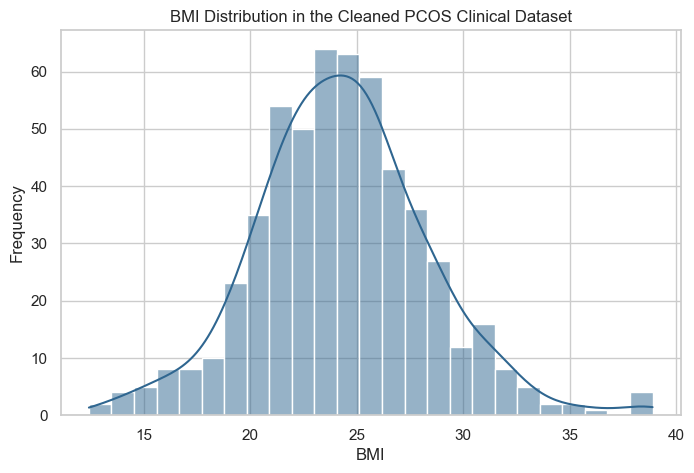

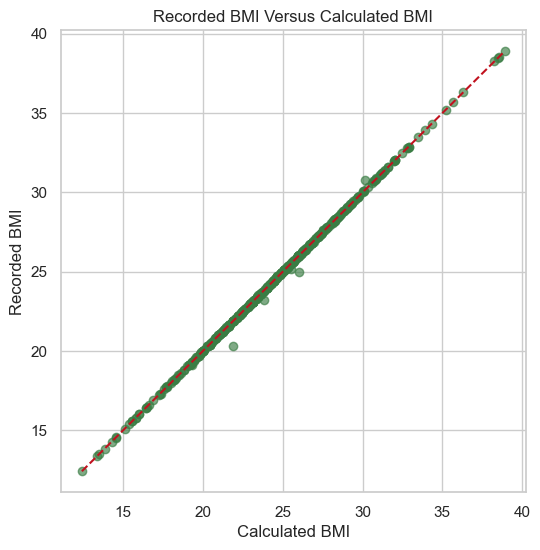

### Remaining Missingness After Cleaning

,column,missing_count,missing_percentage
0,age_yrs,0,0.000
1,amh_ng_ml,0,0.000
2,avg_follicle_size_left_mm,0,0.000
3,avg_follicle_size_right_mm,0,0.000
4,beta_hcg_i_miu_ml,0,0.000
5,beta_hcg_ii_miu_ml,0,0.000
6,blood_group_code,0,0.000
7,bmi,0,0.000
8,bmi_calculated,0,0.000
9,cycle_length_days,0,0.000


### Binary Encoding Validation

,column,unique_non_null_values
0,pcos_y_n,"0, 1"
1,pregnant_y_n,"0, 1"
2,weight_gain_y_n,"0, 1"
3,hair_growth_y_n,"0, 1"
4,skin_darkening_y_n,"0, 1"
5,hair_loss_y_n,"0, 1"
6,pimples_y_n,"0, 1"
7,fast_food_y_n,"0, 1"
8,regular_exercise_y_n,"0, 1"


### Numeric Range Flags

,column,lower_bound,upper_bound,flagged_rows
0,pulse_rate_bpm,30.000,220,2
1,cycle_length_days,1.000,365,1
2,systolic_bp_mmhg,70.000,250,1
3,diastolic_bp_mmhg,40.000,150,1
4,endometrium_mm,0.500,30,2


### Saved Diagnostic Figures

,saved_figure
0,pcos_full_bmi_distribution.png
1,pcos_full_bmi_recorded_vs_calculated.png


In [8]:
# Summarizing remaining missingness after cleaning confirms whether the dataset is ready for downstream analysis.
remaining_missing_summary = (
    pd.DataFrame(
        {
            'column': df_clean.columns,
            'missing_count': df_clean.isna().sum().values,
            'missing_percentage': (df_clean.isna().sum().values / len(df_clean)) * 100,
        }
    )
    .sort_values(['missing_count', 'column'], ascending=[False, True])
    .reset_index(drop=True)
)

# Listing unique values in binary columns makes the final categorical validation explicit.
binary_post_validation_df = pd.DataFrame(
    [
        {
            'column': column,
            'unique_non_null_values': ', '.join(map(str, sorted(pd.Series(df_clean[column].dropna().unique()).tolist()))),
        }
        for column in binary_columns
        if column in df_clean.columns
    ]
)

# Saving a BMI distribution figure provides a lightweight diagnostic visual that later notebooks can reference if needed.
saved_figures = []
if 'bmi' in df_clean.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    if sns is not None:
        sns.histplot(df_clean['bmi'], kde=True, bins=25, ax=ax, color='#2f6690')
    else:
        ax.hist(df_clean['bmi'].dropna(), bins=25, color='#2f6690', edgecolor='white', alpha=0.9)
    ax.set_title('BMI Distribution in the Cleaned PCOS Clinical Dataset')
    ax.set_xlabel('BMI')
    ax.set_ylabel('Frequency')
    bmi_figure_path = IMAGE_DIR / 'pcos_full_bmi_distribution.png'
    fig.savefig(bmi_figure_path, dpi=300, bbox_inches='tight')
    saved_figures.append(bmi_figure_path.name)
    plt.show()

# Saving a recorded-versus-calculated BMI scatter plot helps audit agreement between stored and derived anthropometric values.
if {'bmi', 'bmi_calculated'}.issubset(df_clean.columns):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(df_clean['bmi_calculated'], df_clean['bmi'], alpha=0.65, color='#3a7d44')
    axis_min = float(min(df_clean['bmi_calculated'].min(), df_clean['bmi'].min()))
    axis_max = float(max(df_clean['bmi_calculated'].max(), df_clean['bmi'].max()))
    ax.plot([axis_min, axis_max], [axis_min, axis_max], linestyle='--', color='#c1121f')
    ax.set_title('Recorded BMI Versus Calculated BMI')
    ax.set_xlabel('Calculated BMI')
    ax.set_ylabel('Recorded BMI')
    bmi_compare_figure_path = IMAGE_DIR / 'pcos_full_bmi_recorded_vs_calculated.png'
    fig.savefig(bmi_compare_figure_path, dpi=300, bbox_inches='tight')
    saved_figures.append(bmi_compare_figure_path.name)
    plt.show()

display(Markdown('### Remaining Missingness After Cleaning'))
display(remaining_missing_summary)
display(Markdown('### Binary Encoding Validation'))
display(binary_post_validation_df)
display(Markdown('### Numeric Range Flags'))
display(range_issues_df if not range_issues_df.empty else pd.DataFrame({'message': ['No range violations were flagged by the configured sanity checks.']}))
display(Markdown('### Saved Diagnostic Figures'))
display(pd.DataFrame({'saved_figure': saved_figures if saved_figures else ['No figures were generated.']}))

## Dataset Export and Cleaning Summary

The final step is exporting the cleaned dataset and saving supporting logs only when material cleaning changes have been made. This is keeping the output reproducible while avoiding silent overwrites with unchanged data.

In [9]:
# Converting the transformation history into a dataframe makes the cleaning record easy to inspect and save.
transformation_log_df = pd.DataFrame(transformation_log)

# Building a compact quality summary table provides a thesis-friendly snapshot of the before-and-after state.
quality_summary_df = pd.DataFrame(
    {
        'check': [
            'Rows in raw dataset',
            'Columns in raw dataset',
            'Rows in cleaned dataset',
            'Columns in cleaned dataset',
            'Exact duplicate rows in raw data',
            'Duplicate rows removed after identifier drop',
            'Rows with missing target removed',
            'Columns renamed',
            'Range flags handled',
            'Remaining missing cells after cleaning',
        ],
        'value': [
            df_raw.shape[0],
            df_raw.shape[1],
            df_clean.shape[0],
            df_clean.shape[1],
            raw_duplicate_rows,
            duplicate_rows_after_identifier_drop,
            missing_target_rows,
            columns_renamed_count,
            int(range_issues_df['flagged_rows'].sum()) if not range_issues_df.empty else 0,
            int(df_clean.isna().sum().sum()),
        ],
    }
)

# Determining whether changes were made prevents unnecessary export messages and clarifies notebook behavior.
changes_made = any(
    [
        bool(empty_columns),
        bool(identifier_columns),
        columns_renamed_count > 0,
        duplicate_rows_after_identifier_drop > 0,
        missing_target_rows > 0,
        not imputation_log_df.empty,
        not range_issues_df.empty,
        bmi_missing_before > 0,
        waist_hip_missing_before > 0,
    ]
)

# Defining export paths once keeps the saved outputs consistent with the project structure.
cleaned_dataset_path = CLEANED_DIR / 'PCOS_full_cleaned.csv'
transformation_log_path = CLEANED_DIR / 'PCOS_full_cleaning_log.csv'
quality_summary_path = CLEANED_DIR / 'PCOS_full_quality_summary.csv'

# Saving outputs only when changes have been applied keeps the notebook behavior explicit and reproducible.
if changes_made:
    df_clean.to_csv(cleaned_dataset_path, index=False)
    transformation_log_df.to_csv(transformation_log_path, index=False)
    quality_summary_df.to_csv(quality_summary_path, index=False)
    display(Markdown(f'**Cleaned dataset saved to:** `{cleaned_dataset_path}`'))
    display(Markdown(f'**Transformation log saved to:** `{transformation_log_path}`'))
    display(Markdown(f'**Quality summary saved to:** `{quality_summary_path}`'))
else:
    display(Markdown('**No material cleaning changes were detected, so no cleaned CSV was written.**'))

display(Markdown('### Cleaning Summary Table'))
display(quality_summary_df)
display(Markdown('### Transformation Log'))
display(transformation_log_df if not transformation_log_df.empty else pd.DataFrame({'message': ['No transformations were recorded.']}))

# Displaying the first rows of the cleaned dataset gives a final confirmation of the exported structure.
df_clean.head(10)

**Cleaned dataset saved to:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\PCOS_full_cleaned.csv`

**Transformation log saved to:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\PCOS_full_cleaning_log.csv`

**Quality summary saved to:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\PCOS_full_quality_summary.csv`

### Cleaning Summary Table

,check,value
0,Rows in raw dataset,541
1,Columns in raw dataset,45
2,Rows in cleaned dataset,541
3,Columns in cleaned dataset,44
4,Exact duplicate rows in raw data,0
5,Duplicate rows removed after identifier drop,0
6,Rows with missing target removed,0
7,Columns renamed,42
8,Range flags handled,7
9,Remaining missing cells after cleaning,0


### Transformation Log

,step,detail,affected_items
0,Dropped empty columns,Removed workbook artefact columns: ['Unnamed: ...,1
1,Dropped identifier columns,Removed non-informative identifier columns: ['...,2
2,Standardized column names,Renamed clinical variables to stable snake_cas...,42
3,Applied range sanity checks,Set implausible values to missing in pulse_rat...,2
4,Applied range sanity checks,Set implausible values to missing in cycle_len...,1
5,Applied range sanity checks,Set implausible values to missing in systolic_...,1
6,Applied range sanity checks,Set implausible values to missing in diastolic...,1
7,Applied range sanity checks,Set implausible values to missing in endometri...,2
8,Imputed categorical-like column,Filled missing values in fast_food_y_n using t...,1
9,Imputed continuous column,Filled missing values in pulse_rate_bpm using ...,2


,pcos_y_n,age_yrs,weight_kg,height_cm,bmi,blood_group_code,pulse_rate_bpm,respiratory_rate_breaths_min,hb_g_dl,cycle_regularity_code,cycle_length_days,marriage_status_yrs,pregnant_y_n,number_of_abortions,beta_hcg_i_miu_ml,beta_hcg_ii_miu_ml,fsh_miu_ml,lh_miu_ml,fsh_lh_ratio,hip_inch,waist_inch,waist_hip_ratio,tsh_miu_l,amh_ng_ml,prl_ng_ml,vit_d3_ng_ml,prg_ng_ml,rbs_mg_dl,weight_gain_y_n,hair_growth_y_n,skin_darkening_y_n,hair_loss_y_n,pimples_y_n,fast_food_y_n,regular_exercise_y_n,systolic_bp_mmhg,diastolic_bp_mmhg,follicle_no_left,follicle_no_right,avg_follicle_size_left_mm,avg_follicle_size_right_mm,endometrium_mm,bmi_calculated,waist_hip_ratio_calculated
0,0,28,44.600,152.000,19.300,15,78.000,22,10.480,2,5.000,7.000,0,0,1.990,1.990,7.950,3.680,2.160,36,30,0.833,0.680,2.070,45.160,17.100,0.570,92.000,0,0,0,0,0,1,0,110.000,80.000,3,3,18.000,18.000,8.500,19.304,0.833
1,0,36,65.000,161.500,24.921,15,74.000,20,11.700,2,5.000,11.000,1,0,60.800,1.990,6.730,1.090,6.174,38,32,0.842,3.160,1.530,20.090,61.300,0.970,92.000,0,0,0,0,0,0,0,120.000,70.000,3,5,15.000,14.000,3.700,24.921,0.842
2,1,33,68.800,165.000,25.271,11,72.000,18,11.800,2,5.000,10.000,1,0,494.080,494.080,5.540,0.880,6.295,40,36,0.900,2.540,6.630,10.520,49.700,0.360,84.000,0,0,0,1,1,1,0,120.000,80.000,13,15,18.000,20.000,10.000,25.271,0.900
3,0,37,65.000,148.000,29.675,13,72.000,20,12.000,2,5.000,4.000,0,0,1.990,1.990,8.060,2.360,3.415,42,36,0.857,16.410,1.220,36.900,33.400,0.360,76.000,0,0,0,0,0,0,0,120.000,70.000,2,2,15.000,14.000,7.500,29.675,0.857
4,0,25,52.000,161.000,20.061,11,72.000,18,10.000,2,5.000,1.000,1,0,801.450,801.450,3.980,0.900,4.422,37,30,0.811,3.570,2.260,30.090,43.800,0.380,84.000,0,0,0,1,0,0,0,120.000,80.000,3,4,16.000,14.000,7.000,20.061,0.811
5,0,36,74.100,165.000,27.218,15,78.000,28,11.200,2,5.000,8.000,1,0,237.970,1.990,3.240,1.070,3.028,44,38,0.864,1.600,6.740,16.180,52.400,0.300,76.000,1,0,0,1,0,0,0,110.000,70.000,9,6,16.000,20.000,8.000,27.218,0.864
6,0,34,64.000,156.000,26.298,11,72.000,18,10.900,2,5.000,2.000,0,0,1.990,1.990,2.850,0.310,9.194,39,33,0.846,1.510,3.050,26.410,42.700,0.460,93.000,0,0,0,0,0,0,0,120.000,80.000,6,6,15.000,16.000,6.800,26.298,0.846
7,0,33,58.500,159.000,23.140,13,72.000,20,11.000,2,5.000,13.000,1,2,100.510,100.510,4.860,3.070,1.583,44,38,0.864,12.180,1.540,3.970,38.000,0.260,91.000,1,0,0,0,0,0,0,120.000,80.000,7,6,15.000,18.000,7.100,23.140,0.864
8,0,32,40.000,158.000,16.023,11,72.000,18,11.800,2,5.000,8.000,0,1,1.990,1.990,3.760,3.020,1.245,39,35,0.897,1.510,1.000,19.000,21.800,0.300,116.000,0,0,0,0,0,0,0,120.000,80.000,5,7,17.000,17.000,4.200,16.023,0.897
9,0,36,52.000,150.000,23.111,15,80.000,20,10.000,4,2.000,4.000,0,0,1.990,1.990,2.800,1.510,1.854,40,38,0.950,6.650,1.610,11.740,27.700,0.250,125.000,0,0,0,0,0,0,0,110.000,80.000,1,1,14.000,17.000,2.500,23.111,0.950


## Final Note

This notebook is completing the foundational cleaning stage for the main clinical PCOS dataset. The resulting cleaned file, transformation log, and diagnostic figures are now being prepared for later exploratory analysis, association testing, and non-invasive predictive modeling in the subsequent notebooks.

At this stage, the workflow is remaining focused on data quality and reproducibility rather than model building.